In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    torch.cuda.manual_seed(0)
    x = torch.tensor([1,2,3], device="cuda")
    print("CUDA ok:", x.sum().item())

CUDA available: True
CUDA ok: 6


In [ ]:
!pip install evaluate emoji==0.6.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.1 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-0.6.0-py3-none-any.whl size=49719 sha256=ce22780dc9da72713565b05bbb76f3ac5d0dbcda7eba547c27b3699cd8e8c794
  Stored in directory: /root/.cache/pip/wheels/0d/bf/a2/536017b4a6232aef0fb92831af35facd6590c0af0f3983f63b
Successfully built emoji


In [ ]:
import os

# Logic to switch between colab and local IDE
is_colab = False
try:
  from google.colab import drive
  drive.mount('/content/drive')
  is_colab = True
except Exception:
  pass

# Define main directory for both Colab and local IDE
candidate_dirs = []
if is_colab:
  candidate_dirs.extend([
    '/content/drive/MyDrive/CS263_final_project',
    '/content/drive/Shareddrives/CS263_final_project',
  ])

# Google Drive for Desktop (local)
candidate_dirs.append(
  '/Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project'
)

main_dir = None
for path in candidate_dirs:
  if os.path.exists(path):
    main_dir = path
    break

if main_dir is None:
  # Fall back to local Drive path and create it if needed
  main_dir = candidate_dirs[-1]
  os.makedirs(main_dir, exist_ok=True)

print(f"Main Directory: {main_dir}")

# Store the clean, downloaded BERT model here
base_model_path = os.path.join(main_dir, "model", "bertweet_base_local")
# Store your training checkpoints here
checkpoint_dir = os.path.join(main_dir, "model", "checkpoints")
# Store the datasets here
dataset_dir = os.path.join(main_dir, "data")

os.makedirs(base_model_path, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(dataset_dir, exist_ok=True)

print(f"Base model will be stored at: {base_model_path}")
print(f"Checkpoints will be saved to: {checkpoint_dir}")
print(f"Datasets will be stored to: {dataset_dir}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Main Directory: /Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project
Base model will be stored at: /Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project/model/bertweet_base_local
Checkpoints will be saved to: /Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project/model/checkpoints
Datasets will be stored to: /Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project/data


## Load Datasets

In [ ]:
from datasets import load_dataset
from huggingface_hub import list_repo_files, hf_hub_download
import os

# Reuse dataset_dir from the setup cell
os.makedirs(dataset_dir, exist_ok=True)

revision = "refs/convert/parquet"
subsets = ["pubhealth_source", "pubhealth_bigbio_pairs"]

repo_files = list_repo_files(
    "bigbio/pubhealth",
    repo_type="dataset",
    revision=revision,
)

def download_split_files(subset_name):
    parquet_files = [
        f for f in repo_files
        if f.startswith(subset_name) and f.endswith(".parquet")
    ]
    if not parquet_files:
        raise RuntimeError(
            f"No parquet files found for subset {subset_name} at {revision}"
        )

    split_files = {"train": [], "validation": [], "test": []}
    for f in parquet_files:
        if "/train/" in f:
            split = "train"
        elif "/validation/" in f:
            split = "validation"
        elif "/test/" in f:
            split = "test"
        else:
            split = "train"

        local_path = os.path.join(dataset_dir, f)
        if os.path.exists(local_path):
            split_files[split].append(local_path)
        else:
            split_files[split].append(
                hf_hub_download(
                    repo_id="bigbio/pubhealth",
                    repo_type="dataset",
                    filename=f,
                    revision=revision,
                    local_dir=dataset_dir,
                    local_dir_use_symlinks=False,
                )
            )

    # Remove empty splits to avoid errors
    return {k: v for k, v in split_files.items() if v}

source_files = download_split_files("pubhealth_source")
print(f"Source files: {source_files}")
pair_files = download_split_files("pubhealth_bigbio_pairs")
print(f"Pair files: {pair_files}")

# Load each subset separately (different schemas)
source_ds = load_dataset("parquet", data_files=source_files)
pair_ds = load_dataset("parquet", data_files=pair_files)

index = 3
display(source_ds["train"][index])
display(pair_ds["train"][index])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Source files: {'train': ['/Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project/data/pubhealth_source/train/0000.parquet'], 'validation': ['/Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project/data/pubhealth_source/validation/0000.parquet'], 'test': ['/Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project/data/pubhealth_source/test/0000.parquet']}
Pair files: {'train': ['/Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project/data/pubhealth_bigbio_pairs/train/0000.parquet'], 'validation': ['/Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project/data/pubhealth_bigbio_pairs/validation/0000.parquet'], 'test': ['/Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project/data/pubhealth_bigbio_pairs/test/0000.parquet']}


{'claim_id': '10166',
 'claim': 'Study: Vaccine for Breast, Ovarian Cancer Has Potential',
 'date_published': 'November 8, 2011',
 'explanation': 'While the story does many things well, the overall framing of the story is that the vaccine “shows promise,” when the evidence actually points in the other direction. Because only one patient in the study remains cancer free and because that patient may very well have benefited from an earlier cancer vaccine and other complicating factors, we question the decision to write this story in the first place. Right now, there more than 10,000 cancer-related clinical trials recruiting patients. Cancer has foiled scientists repeatedly with treatments that initially seemed promising in the laboratory or in a very small group of people and later proved unworkable on a larger scale. It’s a difficult task — but a crucial one — for reporters to ask tough questions of the evidence and a wide range of sources before deciding whether one of these thousands 

{'id': '3',
 'document_id': '10166',
 'text_1': 'Study: Vaccine for Breast, Ovarian Cancer Has Potential',
 'text_2': 'While the story does many things well, the overall framing of the story is that the vaccine “shows promise,” when the evidence actually points in the other direction. Because only one patient in the study remains cancer free and because that patient may very well have benefited from an earlier cancer vaccine and other complicating factors, we question the decision to write this story in the first place. Right now, there more than 10,000 cancer-related clinical trials recruiting patients. Cancer has foiled scientists repeatedly with treatments that initially seemed promising in the laboratory or in a very small group of people and later proved unworkable on a larger scale. It’s a difficult task — but a crucial one — for reporters to ask tough questions of the evidence and a wide range of sources before deciding whether one of these thousands of experimental treatment op

## Import HuggingFace Model and save to local drive (BERT) for Finetune

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
model_name = "vinai/bertweet-base"  # Or any other model
num_labels = 3

print("Loading model from Hub...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

print("Saving model to Drive...")
tokenizer.save_pretrained(base_model_path)
model.save_pretrained(base_model_path)

Loading model from Hub...


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Saving model to Drive...


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps")

model.to(device)
model.eval() # Set model to evaluation mode (turns off dropout, etc.)
print("Model loaded successfully.")

Model loaded successfully.


## Fine-tuning plan

1. Map the dataset label column to `labels` for Trainer compatibility.
2. Build a single input text per example (e.g., `claim` + `main_text`).
3. Tokenize with the BERTweet tokenizer and remove unused columns.
4. Train with `Trainer` using the train split and validate each epoch.
5. Evaluate once on the test split and save the fine-tuned model.

In [ ]:
# Fine-tune BERTweet on pubhealth_source
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
import evaluate
import numpy as np

# 1) Ensure the label column is named `labels`
if "label" in source_ds["train"].column_names:
    source_ds = source_ds.rename_column("label", "labels")

# Optional: remove all samples with the "unproven" label
# PubHealth label mapping in this notebook: 0=true, 1=false, 2=unproven, 3=mixture
UNPROVEN_LABEL_ID = 2
source_ds = source_ds.filter(lambda x: x["labels"] != UNPROVEN_LABEL_ID)

# Remap label 3 (mixture) to 2 so labels are contiguous (0, 1, 2)
def remap_labels(example):
    if example["labels"] == 3:
        example["labels"] = 2
    return example

source_ds = source_ds.map(remap_labels)

# 2) Build a single input text per example
# def build_texts(batch):
#     texts = [
#         f"claim: {c}  main_text: {m}"
#         for c, m in zip(batch["claim"], batch["main_text"])
#     ]
#     return tokenizer(texts, truncation=True, max_length=128)

# 2) Build a single input text per example
def build_texts(batch):
    texts = [
        f"claim: {c}"
        for c in batch["claim"]
    ]
    return tokenizer(texts, truncation=True, max_length=128)

# 3) Tokenize and drop unused columns
columns_to_remove = [
    c for c in source_ds["train"].column_names if c not in ("labels",)
]

tokenized_ds = source_ds.map(
    build_texts,
    batched=True,
    remove_columns=columns_to_remove,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 4) Metrics
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

# 5) Train (validate each epoch)
training_args = TrainingArguments(
    output_dir=checkpoint_dir,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=torch.cuda.is_available(),
    report_to="none",
)

# Removed 'tokenizer=tokenizer' to fix TypeError
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

# 6) Final test evaluation
test_metrics = trainer.evaluate(tokenized_ds["test"], metric_key_prefix="test")
print(test_metrics)

# 7) Save final model
final_model_dir = os.path.join(checkpoint_dir, "final")
trainer.save_model(final_model_dir)
# Manually save tokenizer since it wasn't passed to Trainer
tokenizer.save_pretrained(final_model_dir)
print(f"Fine-tuned model saved to: {final_model_dir}")

Map:   0%|          | 0/9513 [00:00<?, ? examples/s]

Map:   0%|          | 0/1182 [00:00<?, ? examples/s]

Map:   0%|          | 0/1186 [00:00<?, ? examples/s]

Map:   0%|          | 0/9513 [00:00<?, ? examples/s]

Map:   0%|          | 0/1182 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

{'test_loss': 0.7076083421707153, 'test_accuracy': 0.6593591905564924, 'test_f1_macro': 0.5288505284364161, 'test_runtime': 1.0532, 'test_samples_per_second': 1126.077, 'test_steps_per_second': 18.04, 'epoch': 3.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model saved to: /content/drive/MyDrive/CS263_final_project/model/checkpoints/final


## Test Few False and True Claims

In [ ]:
sample_text = "Study: Vaccine for Breast, Ovarian Cancer Has Potential"
inputs = tokenizer(
    sample_text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

# Move inputs to the same device as the model
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1).squeeze().cpu()
    pred_idx = int(torch.argmax(probs).item())

id2label = {
    0: "true",
    1: "false",
    2: "mixture"
}

print(f"Text:            {sample_text}")
print(f"Predicted class: {id2label[pred_idx]} (index={pred_idx})")
print("Probabilities:  ",[f"{p:.3f}" for p in probs.tolist()])

Text:            Study: Vaccine for Breast, Ovarian Cancer Has Potential
Predicted class: true (index=0)
Probabilities:   ['0.471', '0.230', '0.298']


## Load Intel/misinformation-guard Dataset

In [ ]:
intel_ds = load_dataset("Intel/misinformation-guard")

int_to_text_map = {
    0: "false",
    1: "mostly_true",
    2: "partially_true",
    3: "true"
}

intel_ds = intel_ds.map(
    lambda x: {"label_text": int_to_text_map[x["label"]]}
)

display(intel_ds["train"][1])

{'text': 'Vaccinating children against COVID-19 can reduce the risk of severe illness and hospitalization, but the vaccine does not guarantee complete immunity against the virus.',
 'reasoning': 'This statement is mostly true because numerous studies have shown that COVID-19 vaccines are highly effective in preventing severe illness and hospitalization in children. However, no vaccine is 100% effective, and individuals may still contract the virus even after vaccination. The statement is largely accurate but may lack nuance regarding the limitations of vaccine efficacy.',
 'label': 1,
 'model': 'meta-llama/Meta-Llama-3.1-8B-Instruct',
 'label_text': 'mostly_true'}

## Evaluate on Intel/misinformation-guard

In [ ]:
# Fine-tune BERTweet on pubhealth_source
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
import evaluate
import numpy as np

# Evaluate the PubHealth-tuned model on Intel/misinformation-guard
# Note: adjust this mapping if you want a different interpretation.
intel_to_pubhealth = {
    "false": 1,        # pubhealth: false
    "true": 0,         # pubhealth: true
    "mostly_true": 2,  # pubhealth: mixture (remapped to 2)
    "partially_true": 2,  # pubhealth: mixture (remapped to 2)
}

# Ensure we have the fine-tuned model loaded from disk
final_model_dir = os.path.join(checkpoint_dir, "final")
model = AutoModelForSequenceClassification.from_pretrained(final_model_dir)
tokenizer = AutoTokenizer.from_pretrained(final_model_dir)

model.to(device)
model.eval()

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Rebuild metrics locally (keeps this cell self-contained)
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

# Map Intel labels -> PubHealth labels
intel_ds = intel_ds.map(lambda x: {"labels": intel_to_pubhealth[x["label_text"]]})

# Use the same input format as training ("claim: {text}")
def build_intel_texts(batch):
    texts = [f"claim: {t}" for t in batch["text"]]
    return tokenizer(texts, truncation=True, max_length=128)

columns_to_remove = [
    c for c in intel_ds["train"].column_names if c not in ("labels",)
]

tokenized_intel = intel_ds.map(
    build_intel_texts,
    batched=True,
    remove_columns=columns_to_remove,
)

intel_eval_args = TrainingArguments(
    output_dir=os.path.join(checkpoint_dir, "intel_eval"),
    per_device_eval_batch_size=128,
    report_to="none",
)

intel_trainer = Trainer(
    model=model,
    args=intel_eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

intel_metrics = intel_trainer.evaluate(
    tokenized_intel["test"],
    metric_key_prefix=f"intel_{"test"}",
)
print(intel_metrics)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/26812 [00:00<?, ? examples/s]

Map:   0%|          | 0/6703 [00:00<?, ? examples/s]

Map:   0%|          | 0/8379 [00:00<?, ? examples/s]

Map:   0%|          | 0/26812 [00:00<?, ? examples/s]

Map:   0%|          | 0/6703 [00:00<?, ? examples/s]

Map:   0%|          | 0/8379 [00:00<?, ? examples/s]

{'intel_test_loss': 1.3616745471954346, 'intel_test_model_preparation_time': 0.003, 'intel_test_accuracy': 0.2240124119823368, 'intel_test_f1_macro': 0.1220098803952158, 'intel_test_runtime': 59.248, 'intel_test_samples_per_second': 141.423, 'intel_test_steps_per_second': 1.114}


In [ ]:
# Fine-tune on Intel/misinformation-guard and evaluate on Intel
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
import evaluate
import numpy as np
import os

# 1) Make sure labels column exists
# if "label" in intel_ds["train"].column_names:
#     intel_ds = intel_ds.rename_column("label", "labels")

# 2) Build input text (use Intel "text" field)
def build_intel_texts(batch):
    texts = [f"claim: {t}" for t in batch["text"]]
    return tokenizer(texts, truncation=True, max_length=128)

columns_to_remove = [
    c for c in intel_ds["train"].column_names if c not in ("labels",)
]

tokenized_intel = intel_ds.map(
    build_intel_texts,
    batched=True,
    remove_columns=columns_to_remove,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 3) Metrics
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

# 4) Train on Intel
intel_train_args = TrainingArguments(
    output_dir=os.path.join(checkpoint_dir, "intel_finetune"),
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=torch.cuda.is_available(),
    report_to="none",
)

intel_trainer = Trainer(
    model=model,
    args=intel_train_args,
    train_dataset=tokenized_intel["train"],
    eval_dataset=tokenized_intel["validation"] if "validation" in tokenized_intel else tokenized_intel["train"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

intel_trainer.train()

# 5) Evaluate on Intel test (fallback to validation if no test split)
eval_split = "test" if "test" in tokenized_intel else "validation"
intel_metrics = intel_trainer.evaluate(
    tokenized_intel[eval_split],
    metric_key_prefix=f"intel_{eval_split}",
)
print(intel_metrics)

# 6) Save Intel-tuned model
intel_model_dir = os.path.join(checkpoint_dir, "intel_finetuned_final")
intel_trainer.save_model(intel_model_dir)
tokenizer.save_pretrained(intel_model_dir)
print(f"Intel fine-tuned model saved to: {intel_model_dir}")

Map:   0%|          | 0/26812 [00:00<?, ? examples/s]

Map:   0%|          | 0/6703 [00:00<?, ? examples/s]

Map:   0%|          | 0/8379 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.683070,0.701925,0.656798
2,0.811238,0.588578,0.751753,0.748357
3,0.558671,0.490992,0.805162,0.797077


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

{'intel_test_loss': 0.4967299997806549, 'intel_test_accuracy': 0.8029597804033894, 'intel_test_f1_macro': 0.7946735092244728, 'intel_test_runtime': 15.8427, 'intel_test_samples_per_second': 528.887, 'intel_test_steps_per_second': 8.269, 'epoch': 3.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Intel fine-tuned model saved to: /content/drive/MyDrive/CS263_final_project/model/checkpoints/intel_finetuned_final


## Evaluate PubHealth-only Model (Before Intel Fine-Tuning)

Let's reload the model trained ONLY on PubHealth and evaluate it on the PubHealth test set to get a baseline.

In [ ]:
# Load the PubHealth-only model (saved earlier as 'final')
pubhealth_model_dir = os.path.join(checkpoint_dir, "final")
print(f"Loading baseline model from: {pubhealth_model_dir}")

model_baseline = AutoModelForSequenceClassification.from_pretrained(pubhealth_model_dir)
tokenizer_baseline = AutoTokenizer.from_pretrained(pubhealth_model_dir)

model_baseline.to(device)
model_baseline.eval()

baseline_eval_args = TrainingArguments(
    output_dir=os.path.join(checkpoint_dir, "baseline_eval_pubhealth_output"),
    per_device_eval_batch_size=64,
    report_to="none",
)

baseline_trainer = Trainer(
    model=model_baseline,
    args=baseline_eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Evaluating Baseline (PubHealth-only) model on PubHealth test set...")
pubhealth_baseline_metrics = baseline_trainer.evaluate(
    tokenized_ds["test"],
    metric_key_prefix="test_baseline"
)
print(pubhealth_baseline_metrics)

# --- Plot ROC/PR for Baseline Model ---
print("Generating plots for Baseline model...")
baseline_preds = baseline_trainer.predict(tokenized_ds["test"])
base_logits = baseline_preds.predictions
base_labels = baseline_preds.label_ids
base_probs = torch.nn.functional.softmax(torch.tensor(base_logits), dim=-1).numpy()
y_base_bin = label_binarize(base_labels, classes=[0, 1, 2])

plt.figure(figsize=(10, 5))
for i in range(n_classes):
    if np.sum(y_base_bin[:, i]) > 0:
        fpr, tpr, _ = roc_curve(y_base_bin[:, i], base_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Baseline (PubHealth-Only) ROC Curve')
plt.legend(loc="lower right")
plt.show()

## Re-evaluate on PubHealth (Catastrophic Forgetting Check)

Now we load the model that was fine-tuned on Intel (sequentially after PubHealth) and test it back on the original PubHealth test set to see if performance degraded.

In [ ]:
# Load the Intel-finetuned model
intel_model_dir = os.path.join(checkpoint_dir, "intel_finetuned_final")
print(f"Loading model from: {intel_model_dir}")

model_final = AutoModelForSequenceClassification.from_pretrained(intel_model_dir)
tokenizer_final = AutoTokenizer.from_pretrained(intel_model_dir)

model_final.to(device)
model_final.eval()

# Use the PubHealth test set (tokenized_ds["test"])
# We need to recreate the trainer or just use evaluate()

final_eval_args = TrainingArguments(
    output_dir=os.path.join(checkpoint_dir, "final_eval_pubhealth_output"),
    per_device_eval_batch_size=64,
    report_to="none",
)

final_trainer = Trainer(
    model=model_final,
    args=final_eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Evaluating Intel-tuned model on original PubHealth test set...")
pubhealth_metrics_after_intel = final_trainer.evaluate(
    tokenized_ds["test"],
    metric_key_prefix="test_after_intel"
)
print(pubhealth_metrics_after_intel)

Loading model from: /content/drive/MyDrive/CS263_final_project/model/checkpoints/intel_finetuned_final


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Evaluating Intel-tuned model on original PubHealth test set...


{'test_after_intel_loss': 0.8851791620254517, 'test_after_intel_model_preparation_time': 0.003, 'test_after_intel_accuracy': 0.6087689713322091, 'test_after_intel_f1_macro': 0.5592966101946154, 'test_after_intel_runtime': 3.708, 'test_after_intel_samples_per_second': 319.848, 'test_after_intel_steps_per_second': 5.124}


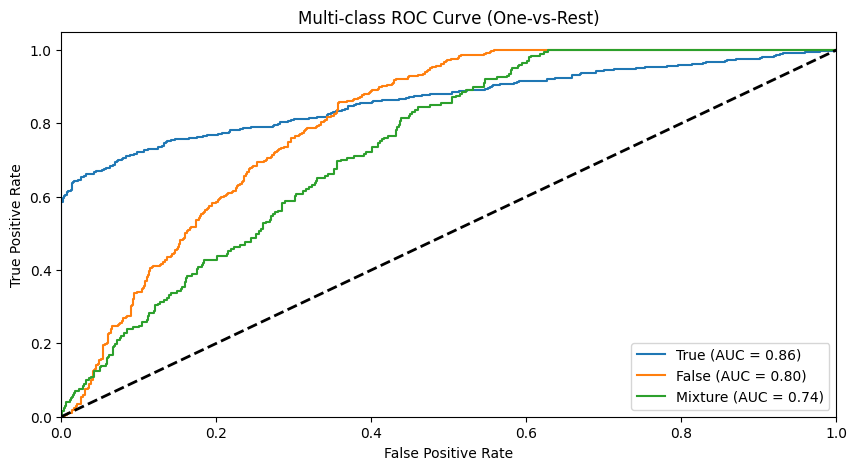

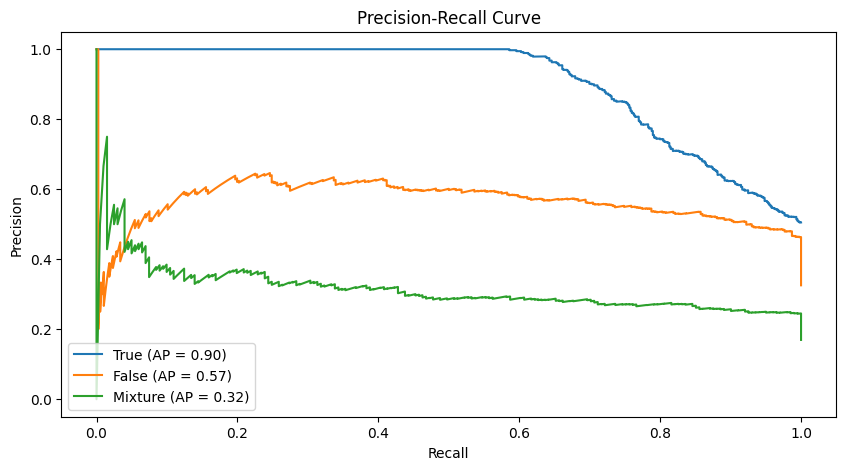

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# 1. Get raw predictions (logits) on the PubHealth test set
predictions_output = final_trainer.predict(tokenized_ds["test"])
logits = predictions_output.predictions
labels = predictions_output.label_ids

# 2. Convert logits to probabilities (softmax)
probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()

# 3. Binarize labels for multi-class ROC/PR (One-vs-Rest)
# PubHealth classes: 0=true, 1=false, 2=unproven, 3=mixture
n_classes = 3
y_test_bin = label_binarize(labels, classes=[0, 1, 2])
class_names = ["True", "False", "Mixture"]

# --- Plot ROC Curve ---
plt.figure(figsize=(10, 5))

# Calculate ROC for each class
for i in range(n_classes):
    if np.sum(y_test_bin[:, i]) > 0:  # Only plot if class exists in test set
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

# --- Plot Precision-Recall Curve ---
plt.figure(figsize=(10, 5))

for i in range(n_classes):
    if np.sum(y_test_bin[:, i]) > 0:
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        avg_precision = average_precision_score(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f'{class_names[i]} (AP = {avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Generating plots for Intel dataset (test split)...


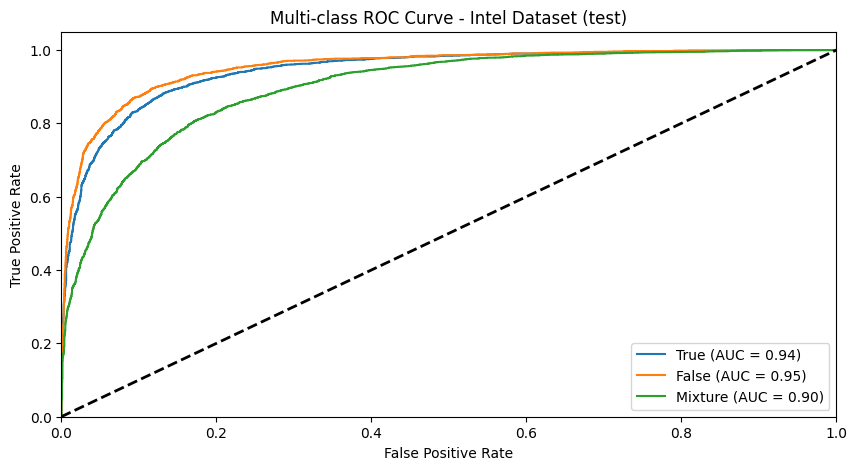

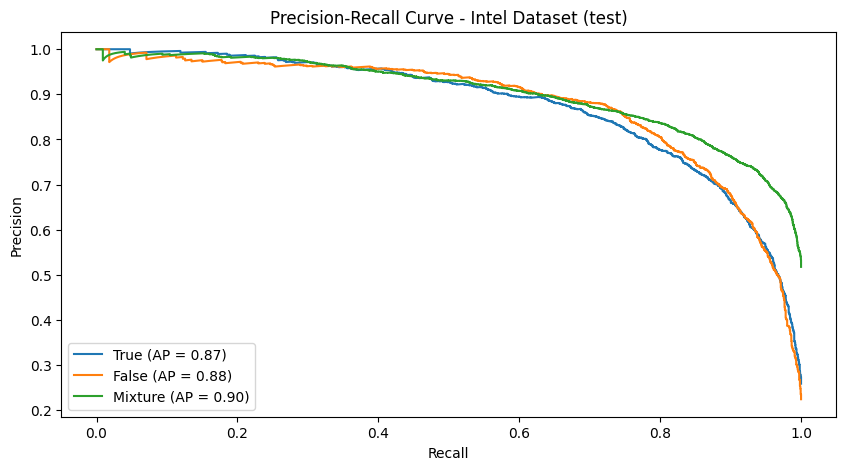

In [ ]:
# --- Evaluate on Intel Dataset ---

# Determine split
eval_split = "test" if "test" in tokenized_intel else "validation"
print(f"Generating plots for Intel dataset ({eval_split} split)...")

# 1. Get raw predictions (logits) on the Intel dataset
intel_predictions_output = final_trainer.predict(tokenized_intel[eval_split])
intel_logits = intel_predictions_output.predictions
intel_labels = intel_predictions_output.label_ids

# 2. Convert logits to probabilities (softmax)
intel_probs = torch.nn.functional.softmax(torch.tensor(intel_logits), dim=-1).numpy()

# 3. Binarize labels
y_intel_bin = label_binarize(intel_labels, classes=[0, 1, 2])

# --- Plot ROC Curve (Intel) ---
plt.figure(figsize=(10, 5))
for i in range(n_classes):
    if np.sum(y_intel_bin[:, i]) > 0:
        fpr, tpr, _ = roc_curve(y_intel_bin[:, i], intel_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Multi-class ROC Curve - Intel Dataset ({eval_split})')
plt.legend(loc="lower right")
plt.show()

# --- Plot Precision-Recall Curve (Intel) ---
plt.figure(figsize=(10, 5))
for i in range(n_classes):
    if np.sum(y_intel_bin[:, i]) > 0:
        precision, recall, _ = precision_recall_curve(y_intel_bin[:, i], intel_probs[:, i])
        avg_precision = average_precision_score(y_intel_bin[:, i], intel_probs[:, i])
        plt.plot(recall, precision, label=f'{class_names[i]} (AP = {avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve - Intel Dataset ({eval_split})')
plt.legend(loc="lower left")
plt.show()

# Improved fine-tuning (recommended): joint training + better PubHealth input + class-imbalance handling

This section is a **cleaner, higher-performing** training pipeline you can use for your Part (2) contribution:
- PubHealth: use `claim + main_text` (or fallback to `claim` if `main_text` is missing)
- Intel/misinformation-guard: map 4-class labels → 3-class `{true, false, mixture}`
- Train **one model jointly** (prevents catastrophic forgetting)
- Use **class-weighted loss** + optional balanced sampling
- Track **accuracy + macro-F1**, plus confusion matrix per dataset

Run this section top-to-bottom.

In [ ]:
!pip install evaluate emoji==0.6.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-0.6.0-py3-none-any.whl size=49719 sha256=75ba67246ca11bd894d1a88ec12174e96ebc89ee70ba579b464815bf0172ad41
  Stored in directory: /root/.cache/pip/wheels/0d/bf/a2/536017b4a6232aef0fb92831af35facd6590c0af0f3983f63b
Successfully built emoji


In [ ]:
import os

# Logic to switch between colab and local IDE
is_colab = False
try:
  from google.colab import drive
  drive.mount('/content/drive')
  is_colab = True
except Exception:
  pass

# Define main directory for both Colab and local IDE
candidate_dirs = []
if is_colab:
  candidate_dirs.extend([
    '/content/drive/MyDrive/CS263_final_project',
    '/content/drive/Shareddrives/CS263_final_project',
  ])

# Google Drive for Desktop (local)
candidate_dirs.append(
  '/Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project'
)

main_dir = None
for path in candidate_dirs:
  if os.path.exists(path):
    main_dir = path
    break

if main_dir is None:
  # Fall back to local Drive path and create it if needed
  main_dir = candidate_dirs[-1]
  os.makedirs(main_dir, exist_ok=True)

print(f"Main Directory: {main_dir}")

# Store the clean, downloaded BERT model here
base_model_path = os.path.join(main_dir, "model", "bertweet_base_local")
# Store your training checkpoints here
checkpoint_dir = os.path.join(main_dir, "model", "checkpoints")
# Store the datasets here
dataset_dir = os.path.join(main_dir, "data")

os.makedirs(base_model_path, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(dataset_dir, exist_ok=True)

print(f"Base model will be stored at: {base_model_path}")
print(f"Checkpoints will be saved to: {checkpoint_dir}")
print(f"Datasets will be stored to: {dataset_dir}")

Mounted at /content/drive
Main Directory: /Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project
Base model will be stored at: /Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project/model/bertweet_base_local
Checkpoints will be saved to: /Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project/model/checkpoints
Datasets will be stored to: /Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project/data


In [ ]:
from datasets import load_dataset
from huggingface_hub import list_repo_files, hf_hub_download
import os

# Reuse dataset_dir from the setup cell
os.makedirs(dataset_dir, exist_ok=True)

revision = "refs/convert/parquet"
subsets = ["pubhealth_source", "pubhealth_bigbio_pairs"]

repo_files = list_repo_files(
    "bigbio/pubhealth",
    repo_type="dataset",
    revision=revision,
)

def download_split_files(subset_name):
    parquet_files = [
        f for f in repo_files
        if f.startswith(subset_name) and f.endswith(".parquet")
    ]
    if not parquet_files:
        raise RuntimeError(
            f"No parquet files found for subset {subset_name} at {revision}"
        )

    split_files = {"train": [], "validation": [], "test": []}
    for f in parquet_files:
        if "/train/" in f:
            split = "train"
        elif "/validation/" in f:
            split = "validation"
        elif "/test/" in f:
            split = "test"
        else:
            split = "train"

        local_path = os.path.join(dataset_dir, f)
        if os.path.exists(local_path):
            split_files[split].append(local_path)
        else:
            split_files[split].append(
                hf_hub_download(
                    repo_id="bigbio/pubhealth",
                    repo_type="dataset",
                    filename=f,
                    revision=revision,
                    local_dir=dataset_dir,
                    local_dir_use_symlinks=False,
                )
            )

    # Remove empty splits to avoid errors
    return {k: v for k, v in split_files.items() if v}

source_files = download_split_files("pubhealth_source")
print(f"Source files: {source_files}")
pair_files = download_split_files("pubhealth_bigbio_pairs")
print(f"Pair files: {pair_files}")

# Load each subset separately (different schemas)
source_ds = load_dataset("parquet", data_files=source_files)
pair_ds = load_dataset("parquet", data_files=pair_files)

index = 3
display(source_ds["train"][index])
display(pair_ds["train"][index])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


pubhealth_source/test/0000.parquet:   0%|          | 0.00/4.03M [00:00<?, ?B/s]

pubhealth_source/train/0000.parquet:   0%|          | 0.00/31.9M [00:00<?, ?B/s]

pubhealth_source/validation/0000.parquet:   0%|          | 0.00/3.95M [00:00<?, ?B/s]

Source files: {'train': ['/Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project/data/pubhealth_source/train/0000.parquet'], 'validation': ['/Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project/data/pubhealth_source/validation/0000.parquet'], 'test': ['/Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project/data/pubhealth_source/test/0000.parquet']}


...

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

{'claim_id': '10166',
 'claim': 'Study: Vaccine for Breast, Ovarian Cancer Has Potential',
 'date_published': 'November 8, 2011',
 'explanation': 'While the story does many things well, the overall framing of the story is that the vaccine “shows promise,” when the evidence actually points in the other direction. Because only one patient in the study remains cancer free and because that patient may very well have benefited from an earlier cancer vaccine and other complicating factors, we question the decision to write this story in the first place. Right now, there more than 10,000 cancer-related clinical trials recruiting patients. Cancer has foiled scientists repeatedly with treatments that initially seemed promising in the laboratory or in a very small group of people and later proved unworkable on a larger scale. It’s a difficult task — but a crucial one — for reporters to ask tough questions of the evidence and a wide range of sources before deciding whether one of these thousands 

{'id': '3',
 'document_id': '10166',
 'text_1': 'Study: Vaccine for Breast, Ovarian Cancer Has Potential',
 'text_2': 'While the story does many things well, the overall framing of the story is that the vaccine “shows promise,” when the evidence actually points in the other direction. Because only one patient in the study remains cancer free and because that patient may very well have benefited from an earlier cancer vaccine and other complicating factors, we question the decision to write this story in the first place. Right now, there more than 10,000 cancer-related clinical trials recruiting patients. Cancer has foiled scientists repeatedly with treatments that initially seemed promising in the laboratory or in a very small group of people and later proved unworkable on a larger scale. It’s a difficult task — but a crucial one — for reporters to ask tough questions of the evidence and a wide range of sources before deciding whether one of these thousands of experimental treatment op

In [ ]:
intel_ds = load_dataset("Intel/misinformation-guard")

int_to_text_map = {
    0: "false",
    1: "mostly_true",
    2: "partially_true",
    3: "true"
}

intel_ds = intel_ds.map(
    lambda x: {"label_text": int_to_text_map[x["label"]]}
)

display(intel_ds["train"][1])

README.md: 0.00B [00:00, ?B/s]

train_data/train.csv:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

val.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/26812 [00:00<?, ? examples/s]

...

Generating test split:   0%|          | 0/8379 [00:00<?, ? examples/s]

Map:   0%|          | 0/26812 [00:00<?, ? examples/s]

Map:   0%|          | 0/6703 [00:00<?, ? examples/s]

Map:   0%|          | 0/8379 [00:00<?, ? examples/s]

{'text': 'Vaccinating children against COVID-19 can reduce the risk of severe illness and hospitalization, but the vaccine does not guarantee complete immunity against the virus.',
 'reasoning': 'This statement is mostly true because numerous studies have shown that COVID-19 vaccines are highly effective in preventing severe illness and hospitalization in children. However, no vaccine is 100% effective, and individuals may still contract the virus even after vaccination. The statement is largely accurate but may lack nuance regarding the limitations of vaccine efficacy.',
 'label': 1,
 'model': 'meta-llama/Meta-Llama-3.1-8B-Instruct',
 'label_text': 'mostly_true'}

In [ ]:
# ===== Experiment config =====
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, TrainingArguments, Trainer,
    EarlyStoppingCallback, set_seed
)
import evaluate
import numpy as np
import torch
import os

set_seed(42)

# Choose your backbone here (you can try 'microsoft/deberta-v3-base' later)
BACKBONE = "vinai/bertweet-base"
NUM_LABELS = 3

# Text formatting
USE_PUBHEALTH_CONTEXT = True   # True = claim + main_text, False = claim only
MAX_LENGTH = 128              # 128 is faster; 256 often helps PubHealth
PREFIX_CLAIM = "[CLAIM]"
PREFIX_CTX   = "[CONTEXT]"

# Training
EPOCHS = 5
LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06
TRAIN_BS = 32
EVAL_BS  = 64
EARLY_STOP_PATIENCE = 2

# Output
joint_out_dir = os.path.join(checkpoint_dir, "joint_pubhealth_intel_weighted")
os.makedirs(joint_out_dir, exist_ok=True)

# Metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

tokenizer_joint = AutoTokenizer.from_pretrained(BACKBONE)

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
from datasets import concatenate_datasets, DatasetDict
from sklearn.utils.class_weight import compute_class_weight
from datasets import Value
from datasets import disable_caching

disable_caching()

# ===== 1) Prepare PubHealth (3-class) =====
# PubHealth label mapping in this notebook: 0=true, 1=false, 2=unproven, 3=mixture
UNPROVEN_LABEL_ID = 2

# Reload PubHealth from parquet files (avoids accidental mutation if earlier baseline cells modified `source_ds`)
# Requires `source_files` from the earlier PubHealth download/load cell.
from datasets import load_dataset
pub = load_dataset("parquet", data_files=source_files)
if "label" in pub["train"].column_names:
    pub = pub.rename_column("label", "labels")

pub = pub.filter(lambda x: x["labels"] != UNPROVEN_LABEL_ID)

def _remap_pubhealth(example):
    # map mixture 3 -> 2
    if example["labels"] == 3:
        example["labels"] = 2
    return example

pub = pub.map(_remap_pubhealth)

def build_pubhealth_texts(batch):
    claims = batch.get("claim", [""] * len(batch[list(batch.keys())[0]]))
    main_texts = batch.get("main_text", [""] * len(claims))
    out = []
    for c, m in zip(claims, main_texts):
        c = "" if c is None else str(c)
        m = "" if m is None else str(m)
        if USE_PUBHEALTH_CONTEXT and m.strip():
            out.append(f"{PREFIX_CLAIM} {c} {PREFIX_CTX} {m}")
        else:
            out.append(f"{PREFIX_CLAIM} {c}")
    return tokenizer_joint(out, truncation=True, max_length=MAX_LENGTH)

pub_cols_to_remove = [c for c in pub["train"].column_names if c != "labels"]
tokenized_pub = pub.map(build_pubhealth_texts, batched=True, remove_columns=pub_cols_to_remove, load_from_cache_file=False)

# ===== 2) Prepare Intel/misinformation-guard (map 4-class -> 3-class) =====
# Intel labels (as ints):
# 0=false, 1=mostly_true, 2=partially_true, 3=true
# Map to PubHealth-style 3-class:
# false -> 1, true -> 0, mostly_true/partially_true -> 2 (mixture)
intel = intel_ds

intel_map = {0: 1, 3: 0, 1: 2, 2: 2}

def _map_intel_labels(ex):
    ex["labels"] = intel_map[int(ex["label"])]
    return ex

intel = intel.map(_map_intel_labels)

def build_intel_texts(batch):
    texts = [f"{PREFIX_CLAIM} {t}" for t in batch["text"]]
    return tokenizer_joint(texts, truncation=True, max_length=MAX_LENGTH)

intel_cols_to_remove = [c for c in intel["train"].column_names if c != "labels"]
tokenized_intel = intel.map(build_intel_texts, batched=True, remove_columns=intel_cols_to_remove, load_from_cache_file=False)

# Cast PubHealth labels to int64 for all splits
for split in tokenized_pub.keys():
    tokenized_pub[split] = tokenized_pub[split].cast_column("labels", Value("int64"))

# Cast Intel labels to int64 for all splits
for split in tokenized_intel.keys():
    tokenized_intel[split] = tokenized_intel[split].cast_column("labels", Value("int64"))

# Some datasets use 'validation' while others don't
intel_val_split = "validation" if "validation" in tokenized_intel else "train"
pub_val_split   = "validation" if "validation" in tokenized_pub else "train"

# ===== 3) Joint training datasets =====
joint = DatasetDict(
    train=concatenate_datasets([tokenized_pub["train"], tokenized_intel["train"]]),
    validation=concatenate_datasets([tokenized_pub[pub_val_split], tokenized_intel[intel_val_split]]),
)

# Keep separate test sets for reporting (fair & interpretable)
pub_test_split = "test" if "test" in tokenized_pub else pub_val_split
intel_test_split = "test" if "test" in tokenized_intel else intel_val_split

pub_test = tokenized_pub[pub_test_split]
intel_test = tokenized_intel[intel_test_split]

print("Joint train size:", len(joint["train"]))
print("Joint val size:", len(joint["validation"]))
print("PubHealth test size:", len(pub_test))
print("Intel test size:", len(intel_test))

# ===== 4) Class weights (helps macro-F1 + 'mixture' class) =====
y_train = np.array(joint["train"]["labels"])
classes = np.unique(y_train)
class_w = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_w = torch.tensor(class_w, dtype=torch.float)
print("Class weights (by class id order):", dict(zip(classes.tolist(), class_w.tolist())))

Filter:   0%|          | 0/9804 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1223 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1231 [00:00<?, ? examples/s]

Map:   0%|          | 0/9513 [00:00<?, ? examples/s]

Map:   0%|          | 0/1182 [00:00<?, ? examples/s]

...

Casting the dataset:   0%|          | 0/1186 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/26812 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/6703 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/8379 [00:00<?, ? examples/s]

Joint train size: 36325
Joint val size: 7885
PubHealth test size: 1186
Intel test size: 8379
Class weights (by class id order): {0: 1.00827157497406, 1: 1.3443248271942139, 2: 0.7909290790557861}


In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler

from transformers import DataCollatorWithPadding

class LongDataCollator(DataCollatorWithPadding):
    def __call__(self, features):
        batch = super().__call__(features)
        # Force correct dtypes for CUDA kernels
        batch["input_ids"] = batch["input_ids"].long()
        if "attention_mask" in batch:
            batch["attention_mask"] = batch["attention_mask"].long()
        if "labels" in batch:
            batch["labels"] = batch["labels"].long()
        return batch

data_collator = LongDataCollator(tokenizer=tokenizer_joint)

# Optional: balanced sampling (helps if one dataset dominates)
USE_WEIGHTED_SAMPLER = True

def _make_sampler(dataset):
    labels = np.array(dataset["labels"])
    counts = np.bincount(labels, minlength=NUM_LABELS)
    # weight per class = inverse frequency
    class_weights = 1.0 / np.clip(counts, 1, None)
    sample_weights = class_weights[labels]
    return WeightedRandomSampler(weights=torch.tensor(sample_weights, dtype=torch.double),
                                num_samples=len(sample_weights),
                                replacement=True)

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, use_weighted_sampler=False, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = class_weights
        self._use_weighted_sampler = use_weighted_sampler

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
      labels = inputs["labels"].long()
      outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
      logits = outputs.get("logits")
      loss_fct = nn.CrossEntropyLoss(
          weight=self._class_weights.to(logits.device) if self._class_weights is not None else None
      )
      loss = loss_fct(logits, labels)
      return (loss, outputs) if return_outputs else loss

    def get_train_dataloader(self):
        if not self._use_weighted_sampler:
            return super().get_train_dataloader()

        train_dataset = self.train_dataset
        sampler = _make_sampler(train_dataset)

        return DataLoader(
            train_dataset,
            batch_size=self.args.per_device_train_batch_size,
            sampler=sampler,
            collate_fn=self.data_collator,
            drop_last=self.args.dataloader_drop_last,
            num_workers=self.args.dataloader_num_workers,
            pin_memory=self.args.dataloader_pin_memory,
        )


# Fresh model for joint training (avoid sequential-forgetting)
model_joint = AutoModelForSequenceClassification.from_pretrained(BACKBONE, num_labels=NUM_LABELS)

print("model max_position_embeddings:", model_joint.config.max_position_embeddings)
print("MAX_LENGTH:", MAX_LENGTH)
assert MAX_LENGTH <= model_joint.config.max_position_embeddings, "MAX_LENGTH too large!"

training_args = TrainingArguments(
    output_dir=joint_out_dir,
    per_device_train_batch_size=TRAIN_BS,
    per_device_eval_batch_size=EVAL_BS,
    num_train_epochs=EPOCHS,
    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    logging_steps=50,
)

trainer_joint = WeightedTrainer(
    model=model_joint,
    args=training_args,
    train_dataset=joint["train"],
    eval_dataset=joint["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_w,
    use_weighted_sampler=USE_WEIGHTED_SAMPLER,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
)

print("pad_token:", tokenizer_joint.pad_token)
print("pad_token_id:", tokenizer_joint.pad_token_id)
print("eos_token_id:", tokenizer_joint.eos_token_id)
print("bos_token_id:", tokenizer_joint.bos_token_id)

# Test what the collator actually produces (this includes padding)
tmp = data_collator([joint["train"][0], joint["train"][1]])
print("batch input_ids min/max:", tmp["input_ids"].min().item(), tmp["input_ids"].max().item())
print("vocab_model:", model_joint.get_input_embeddings().num_embeddings)

trainer_joint.train()

# Save best model + tokenizer
best_dir = os.path.join(joint_out_dir, "best")
trainer_joint.save_model(best_dir)
tokenizer_joint.save_pretrained(best_dir)
print("Saved best joint model to:", best_dir)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

model max_position_embeddings: 130
MAX_LENGTH: 128


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best joint model to: /Users/richardlee/Library/CloudStorage/GoogleDrive-rlee8517@g.ucla.edu/My Drive/CS263_final_project/model/checkpoints/joint_pubhealth_intel_weighted/best


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

def eval_and_report(ds, name):
    metrics = trainer_joint.evaluate(ds, metric_key_prefix=name)
    preds = trainer_joint.predict(ds)
    y_true = preds.label_ids
    y_pred = np.argmax(preds.predictions, axis=-1)
    print(f"\n==== {name} metrics ====")
    print(metrics)
    print(f"\n==== {name} confusion matrix (rows=true, cols=pred) ====")
    print(confusion_matrix(y_true, y_pred, labels=[0,1,2]))
    print(f"\n==== {name} per-class report ====")
    print(classification_report(y_true, y_pred, labels=[0,1,2], target_names=["true","false","mixture"], digits=4))

eval_and_report(pub_test, "pubhealth_test")
eval_and_report(intel_test, "intel_test")

early stopping required metric_for_best_model, but did not find eval_f1_macro so early stopping is disabled



==== pubhealth_test metrics ====
{'pubhealth_test_loss': 0.9523641467094421, 'pubhealth_test_accuracy': 0.6981450252951096, 'pubhealth_test_f1_macro': 0.5828774282623149, 'pubhealth_test_runtime': 2.5362, 'pubhealth_test_samples_per_second': 467.625, 'pubhealth_test_steps_per_second': 7.491, 'epoch': 5.0}

==== pubhealth_test confusion matrix (rows=true, cols=pred) ====
[[503  69  27]
 [ 62 288  36]
 [ 66  98  37]]

==== pubhealth_test per-class report ====
              precision    recall  f1-score   support

        true     0.7971    0.8397    0.8179       599
       false     0.6330    0.7461    0.6849       386
     mixture     0.3700    0.1841    0.2458       201

    accuracy                         0.6981      1186
   macro avg     0.6000    0.5900    0.5829      1186
weighted avg     0.6713    0.6981    0.6777      1186



early stopping required metric_for_best_model, but did not find eval_f1_macro so early stopping is disabled



==== intel_test metrics ====
{'intel_test_loss': 0.2594738304615021, 'intel_test_accuracy': 0.9213509965389665, 'intel_test_f1_macro': 0.919924577357711, 'intel_test_runtime': 10.9487, 'intel_test_samples_per_second': 765.299, 'intel_test_steps_per_second': 11.965, 'epoch': 5.0}

==== intel_test confusion matrix (rows=true, cols=pred) ====
[[1960    5  201]
 [  12 1745  120]
 [ 173  148 4015]]

==== intel_test per-class report ====
              precision    recall  f1-score   support

        true     0.9138    0.9049    0.9093      2166
       false     0.9194    0.9297    0.9245      1877
     mixture     0.9260    0.9260    0.9260      4336

    accuracy                         0.9214      8379
   macro avg     0.9197    0.9202    0.9199      8379
weighted avg     0.9213    0.9214    0.9213      8379



## Optional: add CoAID (if you decide to train on it)

For **true out-of-domain testing**, do **NOT** train on CoAID; just evaluate on it.

If you want a “best possible” model, you can add CoAID to the joint training set:
1) load CoAID with `load_dataset(...)`
2) map its labels into the same `{true,false,mixture}` space
3) build its input text (title + body, etc.)
4) tokenize with the same tokenizer and `MAX_LENGTH`
5) concatenate its train/val splits into `joint`

Make sure you keep CoAID’s test split separate for reporting.

In [ ]:
# ===== OOD Test: CoAID =====
import numpy as np
from datasets import load_dataset, Value
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Use your existing trained trainer/model/tokenizer:
# - trainer_joint
# - model_joint (or trainer_joint.model)
# - tokenizer_joint
# - PREFIX_CLAIM
# - MAX_LENGTH (or set explicitly)
# - NUM_LABELS = 3 (true/false/mixture)

# 1) Load CoAID (as a config inside ComplexDataLab/Misinfo_Datasets)
coaid = load_dataset("ComplexDataLab/Misinfo_Datasets", "coaid")
print("CoAID splits:", list(coaid.keys()))
print("CoAID columns:", coaid["test"].column_names)

# Choose split for OOD evaluation
coaid_split = "test" if "test" in coaid else ("validation" if "validation" in coaid else "train")
coaid_eval = coaid[coaid_split]
print("Using CoAID split:", coaid_split, "size:", len(coaid_eval))

# 2) Pick text + label columns robustly
cols = set(coaid_eval.column_names)

def pick_first(candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

label_col = pick_first(["labels", "label", "class", "target", "veracity"])
text_col  = pick_first(["text", "content", "claim", "statement", "news", "article", "body"])
title_col = pick_first(["title", "headline"])

if label_col is None:
    raise ValueError(f"Could not find label column in {cols}")
if text_col is None and title_col is None:
    raise ValueError(f"Could not find text/title column in {cols}")

print("Detected label column:", label_col)
print("Detected text column:", text_col, "| title column:", title_col)

# 3) Build binary label mapping for CoAID -> your {0:true, 1:false, 2:mixture}
# CoAID is typically binary (real/fake). We'll map:
# real/true -> 0
# fake/false -> 1
# (no mixture labels in CoAID)
#
# If labels are ints and you’re unsure which is real/fake, we’ll infer from ClassLabel names if available;
# otherwise assume 0=real, 1=fake (common), and print unique values for sanity.

features = coaid_eval.features
label_feat = features.get(label_col, None)

def normalize_label(x):
    # returns 0 or 1
    if isinstance(x, str):
        s = x.strip().lower()
        if s in ["real", "true", "legit", "genuine", "non-rumor", "nonrumor", "nonfake"]:
            return 0
        if s in ["fake", "false", "rumor", "misinformation", "hoax"]:
            return 1
        # fallback: try numeric strings
        try:
            xi = int(s)
            return int(xi)
        except:
            raise ValueError(f"Unrecognized string label: {x}")
    else:
        return int(x)

# If ClassLabel exists, prefer its names for mapping
label_name_to_bin = None
if hasattr(label_feat, "names") and label_feat.names is not None:
    names = [n.lower() for n in label_feat.names]
    # attempt to detect which id corresponds to real vs fake
    label_name_to_bin = {}
    for i, n in enumerate(names):
        if any(k in n for k in ["real", "true", "legit", "genuine", "non"]):
            label_name_to_bin[i] = 0
        elif any(k in n for k in ["fake", "false", "rumor", "misinfo", "hoax"]):
            label_name_to_bin[i] = 1
    print("ClassLabel names:", label_feat.names)
    print("Inferred mapping from ClassLabel ids -> bin:", label_name_to_bin)

def map_coaid_label(ex):
    y = ex[label_col]
    yi = normalize_label(y)
    if label_name_to_bin is not None and yi in label_name_to_bin:
        ex["labels"] = int(label_name_to_bin[yi])
    else:
        # default assumption: 0=real/true, 1=fake/false
        ex["labels"] = int(yi)
    # force into {0,1}
    if ex["labels"] not in (0, 1):
        raise ValueError(f"CoAID label not binary after mapping: {ex['labels']} (raw={y})")
    return ex

coaid_eval = coaid_eval.map(map_coaid_label)

print("CoAID unique mapped labels:", np.unique(coaid_eval["labels"], return_counts=True))

# 4) Tokenize CoAID using the SAME tokenizer as your joint model
# Make sure max_length respects the model's positional limit.
model_for_eval = trainer_joint.model if "trainer_joint" in globals() else model_joint
max_pos = getattr(model_for_eval.config, "max_position_embeddings", 512)
eval_max_len = min(MAX_LENGTH, max_pos - 2) if "MAX_LENGTH" in globals() else min(256, max_pos - 2)
print("eval_max_len:", eval_max_len, "| model max_position_embeddings:", max_pos)

def build_coaid_texts(batch):
    texts = []
    if text_col is not None:
        raw_texts = batch[text_col]
        if title_col is not None and title_col in batch:
            raw_titles = batch[title_col]
            for t, b in zip(raw_titles, raw_texts):
                tt = "" if t is None else str(t)
                bb = "" if b is None else str(b)
                if tt.strip():
                    texts.append(f"{PREFIX_CLAIM} {tt} {bb}")
                else:
                    texts.append(f"{PREFIX_CLAIM} {bb}")
        else:
            for b in raw_texts:
                bb = "" if b is None else str(b)
                texts.append(f"{PREFIX_CLAIM} {bb}")
    else:
        # no body, only title
        raw_titles = batch[title_col]
        for t in raw_titles:
            tt = "" if t is None else str(t)
            texts.append(f"{PREFIX_CLAIM} {tt}")

    return tokenizer_joint(texts, truncation=True, max_length=eval_max_len)

coaid_cols_to_remove = [c for c in coaid_eval.column_names if c != "labels"]
coaid_tok = coaid_eval.map(build_coaid_texts, batched=True, remove_columns=coaid_cols_to_remove)
coaid_tok = coaid_tok.cast_column("labels", Value("int64"))

# 5) Predict with your joint model
pred = trainer_joint.predict(coaid_tok)
logits = pred.predictions
y_true = np.array(coaid_tok["labels"])

# (A) Binary prediction ignoring class-2 (mixture) logit:
# take argmax over logits[:, [0,1]]
bin_logits = logits[:, [0, 1]]
y_pred_bin = np.argmax(bin_logits, axis=1)

# (B) Also report how often the model's full 3-class argmax chooses "mixture"
y_pred_3 = np.argmax(logits, axis=1)
mixture_rate = float(np.mean(y_pred_3 == 2))

acc = accuracy_score(y_true, y_pred_bin)
f1m = f1_score(y_true, y_pred_bin, average="macro")

print("\n=== CoAID OOD (Binary eval: true vs false) ===")
print("Accuracy:", acc)
print("Macro-F1:", f1m)
print("Confusion matrix (rows=true labels 0/1, cols=pred 0/1):\n", confusion_matrix(y_true, y_pred_bin))
print("Report:\n", classification_report(y_true, y_pred_bin, digits=4))

print("\n=== Extra diagnostic ===")
print("Mixture/abstain rate (full 3-class argmax == 2):", mixture_rate)

README.md: 0.00B [00:00, ?B/s]

coaid/coaid_train.parquet:   0%|          | 0.00/5.97M [00:00<?, ?B/s]

coaid/coaid_test.parquet:   0%|          | 0.00/2.53M [00:00<?, ?B/s]

coaid/coaid_validation.parquet:   0%|          | 0.00/1.64M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/195143 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/55757 [00:00<?, ? examples/s]

CoAID unique mapped labels: (array([0, 1]), array([52106,  3651]))
eval_max_len: 128 | model max_position_embeddings: 130


Map:   0%|          | 0/55757 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/55757 [00:00<?, ? examples/s]


=== CoAID OOD (Binary eval: true vs false) ===
Accuracy: 0.6645264271750633
Macro-F1: 0.4978386698938823
Confusion matrix (rows=true labels 0/1, cols=pred 0/1):
 [[34588 17518]
 [ 1187  2464]]
Report:
               precision    recall  f1-score   support

           0     0.9668    0.6638    0.7872     52106
           1     0.1233    0.6749    0.2085      3651

    accuracy                         0.6645     55757
   macro avg     0.5451    0.6693    0.4978     55757
weighted avg     0.9116    0.6645    0.7493     55757


=== Extra diagnostic ===
Mixture/abstain rate (full 3-class argmax == 2): 0.6144878669942787


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# logits from trainer_joint.predict(coaid_tok)
pred = trainer_joint.predict(coaid_tok)
logits = pred.predictions
y_true = np.array(coaid_tok["labels"])   # 0/1 for CoAID

# Full 3-class prediction
y_pred3 = np.argmax(logits, axis=1)
mixture_mask = (y_pred3 == 2)
coverage = 1.0 - float(mixture_mask.mean())

# Binary prediction using only logits for classes [0,1]
y_pred_bin = np.argmax(logits[:, [0,1]], axis=1)

# Evaluate ONLY on non-mixture predictions (covered subset)
keep = ~mixture_mask
y_true_keep = y_true[keep]
y_pred_keep = y_pred_bin[keep]

print("=== CoAID OOD with abstain-on-mixture ===")
print("Coverage (not mixture):", coverage)
print("Kept samples:", keep.sum(), "/", len(keep))

acc = accuracy_score(y_true_keep, y_pred_keep)
f1m = f1_score(y_true_keep, y_pred_keep, average="macro")
print("Accuracy on covered subset:", acc)
print("Macro-F1 on covered subset:", f1m)
print("Confusion matrix (0/1):\n", confusion_matrix(y_true_keep, y_pred_keep))
print("Report:\n", classification_report(y_true_keep, y_pred_keep, digits=4))

print("\nMixture rate:", float(mixture_mask.mean()))

=== CoAID OOD with abstain-on-mixture ===
Coverage (not mixture): 0.3855121330057213
Kept samples: 21495 / 55757
Accuracy on covered subset: 0.6737380786229356
Macro-F1 on covered subset: 0.5532767330012432
Confusion matrix (0/1):
 [[12822  6576]
 [  437  1660]]
Report:
               precision    recall  f1-score   support

           0     0.9670    0.6610    0.7853     19398
           1     0.2016    0.7916    0.3213      2097

    accuracy                         0.6737     21495
   macro avg     0.5843    0.7263    0.5533     21495
weighted avg     0.8924    0.6737    0.7400     21495


Mixture rate: 0.6144878669942787


In [ ]:
import numpy as np
from datasets import Value
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, f1_score
import torch

# --- helper to tokenize a split the same way as before ---
def tokenize_coaid_split(split_ds):
    cols = set(split_ds.column_names)
    label_col = "label" if "label" in cols else "veracity"
    text_col  = "claim" if "claim" in cols else ("text" if "text" in cols else None)
    assert text_col is not None

    def map_label(ex):
        # raw label strings: real/fake
        y = ex[label_col]
        if isinstance(y, str):
            ex["labels"] = 0 if y.lower() in ["real", "true"] else 1
        else:
            ex["labels"] = int(y)
        return ex

    ds = split_ds.map(map_label)
    cols_to_remove = [c for c in ds.column_names if c != "labels"]

    max_pos = trainer_joint.model.config.max_position_embeddings
    eval_max_len = min(MAX_LENGTH, max_pos - 2)

    def tok(batch):
        texts = [f"{PREFIX_CLAIM} {t}" for t in batch[text_col]]
        return tokenizer_joint(texts, truncation=True, max_length=eval_max_len)

    ds_tok = ds.map(tok, batched=True, remove_columns=cols_to_remove)
    ds_tok = ds_tok.cast_column("labels", Value("int64"))
    return ds_tok

# --- load & tokenize CoAID validation/test ---
coaid = load_dataset("ComplexDataLab/Misinfo_Datasets", "coaid")
coaid_val_tok  = tokenize_coaid_split(coaid["validation"])
coaid_test_tok = tokenize_coaid_split(coaid["test"])

# --- get probabilities for class 1 (fake) from binary logits ---
def get_prob_fake(ds_tok):
    out = trainer_joint.predict(ds_tok)
    logits = out.predictions
    # binary softmax on columns [0,1]
    bin_logits = logits[:, [0,1]]
    probs = torch.softmax(torch.tensor(bin_logits), dim=1).numpy()
    prob_fake = probs[:, 1]
    y_true = np.array(ds_tok["labels"])
    # also track mixture rate from full argmax
    y_pred3 = np.argmax(logits, axis=1)
    mix_rate = float(np.mean(y_pred3 == 2))
    return prob_fake, y_true, mix_rate

p_val, y_val, mix_val = get_prob_fake(coaid_val_tok)
p_test, y_test, mix_test = get_prob_fake(coaid_test_tok)

print("Mixture rate val/test:", mix_val, mix_test)

# --- sweep thresholds on validation, pick best macro-F1 (or target precision) ---
ths = np.linspace(0.05, 0.95, 19)
best = None
rows = []
for th in ths:
    y_pred = (p_val >= th).astype(int)
    acc = accuracy_score(y_val, y_pred)
    f1m = f1_score(y_val, y_pred, average="macro")
    prec, rec, f1, _ = precision_recall_fscore_support(y_val, y_pred, average=None, labels=[0,1], zero_division=0)
    rows.append((th, acc, f1m, prec[1], rec[1], f1[1]))
    if best is None or f1m > best[1]:
        best = (th, f1m)

best_th = best[0]
print("\nBest threshold by val macro-F1:", best_th, "val macro-F1:", best[1])

# --- evaluate on test with chosen threshold ---
y_pred_test = (p_test >= best_th).astype(int)
acc_t = accuracy_score(y_test, y_pred_test)
f1m_t = f1_score(y_test, y_pred_test, average="macro")
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_test, average=None, labels=[0,1], zero_division=0)

print("\n=== CoAID TEST with calibrated threshold ===")
print("Threshold:", best_th)
print("Accuracy:", acc_t)
print("Macro-F1:", f1m_t)
print("Fake precision/recall/F1:", prec[1], rec[1], f1[1])

Map:   0%|          | 0/27878 [00:00<?, ? examples/s]

Map:   0%|          | 0/27878 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/27878 [00:00<?, ? examples/s]

Map:   0%|          | 0/55757 [00:00<?, ? examples/s]

Map:   0%|          | 0/55757 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/55757 [00:00<?, ? examples/s]

Mixture rate val/test: 0.619341416170457 0.6144878669942787

Best threshold by val macro-F1: 0.95 val macro-F1: 0.5699512308813925

=== CoAID TEST with calibrated threshold ===
Threshold: 0.95
Accuracy: 0.8138170991983069
Macro-F1: 0.5728026258986557
Fake precision/recall/F1: 0.17093682769411306 0.4787729389208436 0.2519276500684586


# **Export misclassified examples**

In [ ]:
import os, numpy as np, pandas as pd, torch
from datasets import load_dataset, Value
from sklearn.metrics import classification_report

LABEL_NAMES = {0: "true", 1: "false", 2: "mixture"}

def softmax_np(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

def export_misclassified(
    *,
    trainer,
    tokenizer,
    raw_ds,
    make_input_text,          # function(example)->str
    label_col="labels",
    out_path="/content/misclassified.csv",
    top_k=200,
    include_correct=False,
    sort_by="confidence_wrong" # "confidence_wrong" or "random"
):
    """
    Exports top-k misclassified examples from raw_ds (HF Dataset) to CSV.
    Keeps original columns + predicted label + probabilities.
    """
    # Ensure labels column name
    if label_col != "labels" and "labels" not in raw_ds.column_names:
        raw_ds = raw_ds.rename_column(label_col, "labels")
    elif label_col == "labels" and "labels" not in raw_ds.column_names:
        raise ValueError("raw_ds must contain a 'labels' column (or pass label_col=...).")

    # Add stable index to join predictions back
    raw_ds = raw_ds.add_column("idx", list(range(len(raw_ds))))

    # Tokenize WITHOUT keeping string columns (avoid collator issues)
    max_pos = getattr(trainer.model.config, "max_position_embeddings", 512)
    eval_max_len = min(MAX_LENGTH, max_pos - 2) if "MAX_LENGTH" in globals() else min(128, max_pos - 2)

    def tok_batch(batch):
        # build input texts from raw fields
        texts = []
        # batch is dict of lists; use idx to iterate length
        n = len(batch["idx"])
        for i in range(n):
            ex = {k: batch[k][i] for k in batch.keys()}
            texts.append(make_input_text(ex))
        return tokenizer(texts, truncation=True, max_length=eval_max_len)

    # Remove everything except idx + labels after tokenization
    keep_cols = {"idx", "labels"}
    remove_cols = [c for c in raw_ds.column_names if c not in keep_cols]
    tok_ds = raw_ds.map(tok_batch, batched=True, remove_columns=remove_cols, load_from_cache_file=False)
    tok_ds = tok_ds.cast_column("labels", Value("int64"))

    # Predict
    pred_out = trainer.predict(tok_ds)
    logits = pred_out.predictions
    probs = softmax_np(logits, axis=1)
    y_true = np.array(tok_ds["labels"], dtype=int)
    y_pred = np.argmax(probs, axis=1)
    conf_pred = probs[np.arange(len(y_pred)), y_pred]

    # Filter incorrect
    incorrect_mask = (y_pred != y_true)
    if include_correct:
        selected_idx = np.arange(len(y_true))
    else:
        selected_idx = np.where(incorrect_mask)[0]

    if len(selected_idx) == 0:
        print("No misclassified examples found.")
        return None

    # Sort selection
    if sort_by == "confidence_wrong":
        # sort incorrect examples by how confident the model was in the wrong label
        sel_conf = conf_pred[selected_idx]
        order = np.argsort(-sel_conf)
        selected_idx = selected_idx[order]
    elif sort_by == "random":
        rng = np.random.default_rng(0)
        rng.shuffle(selected_idx)

    selected_idx = selected_idx[:top_k]

    # Build export rows by pulling from raw_ds using idx
    rows = []
    for j in selected_idx:
        j = int(j)
        ridx = int(tok_ds[j]["idx"])
        raw_ex = raw_ds[int(ridx)]  # includes original columns
        yt = int(y_true[j])
        yp = int(y_pred[j])

        row = dict(raw_ex)  # includes all original fields
        row["true_id"] = yt
        row["true_label"] = LABEL_NAMES.get(yt, str(yt))
        row["pred_id"] = yp
        row["pred_label"] = LABEL_NAMES.get(yp, str(yp))
        row["pred_confidence"] = float(conf_pred[j])
        row["prob_true"] = float(probs[j, 0])
        row["prob_false"] = float(probs[j, 1])
        row["prob_mixture"] = float(probs[j, 2])

        # store the actual model input text (useful for your teammate)
        row["model_input_text"] = make_input_text(raw_ex)

        rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(out_path, index=False, encoding="utf-8-sig")
    print(f"Exported {len(df)} examples to: {out_path}")

    # Quick summary
    print("Total examples:", len(y_true))
    print("Misclassified:", int(incorrect_mask.sum()))
    print("Misclass rate:", float(incorrect_mask.mean()))
    print(classification_report(y_true, y_pred, target_names=[LABEL_NAMES[i] for i in sorted(LABEL_NAMES)], digits=4))

    return df

In [ ]:
# --- Load raw PubHealth again (raw columns preserved) ---
pub_raw = load_dataset("parquet", data_files=source_files)

# Rename label column -> labels if needed
if "label" in pub_raw["train"].column_names:
    pub_raw = pub_raw.rename_column("label", "labels")

# Drop unproven (2) and map mixture (3) -> 2, like your training
UNPROVEN_LABEL_ID = 2

def _prep_pub(ex):
    if ex["labels"] == UNPROVEN_LABEL_ID:
        ex["labels"] = -1
    if ex["labels"] == 3:
        ex["labels"] = 2
    return ex

pub_raw = pub_raw.map(_prep_pub)
pub_raw = pub_raw.filter(lambda x: x["labels"] != -1)

pub_test_split = "test" if "test" in pub_raw else ("validation" if "validation" in pub_raw else "train")
pub_test_raw = pub_raw[pub_test_split]

# Build the same input text style you used for training
def make_pub_input(ex):
    c = "" if ex.get("claim") is None else str(ex.get("claim"))
    m = "" if ex.get("main_text") is None else str(ex.get("main_text"))
    if "USE_PUBHEALTH_CONTEXT" in globals() and USE_PUBHEALTH_CONTEXT and m.strip():
        return f"{PREFIX_CLAIM} {c} {PREFIX_CTX} {m}"
    return f"{PREFIX_CLAIM} {c}"

# Export top confident wrong examples (adjust top_k as you like)
pub_csv = "/content/pubhealth_misclassified_top200.csv"
df_pub = export_misclassified(
    trainer=trainer_joint,
    tokenizer=tokenizer_joint,
    raw_ds=pub_test_raw,
    make_input_text=make_pub_input,
    out_path=pub_csv,
    top_k=200,
    sort_by="confidence_wrong"
)

Map:   0%|          | 0/9804 [00:00<?, ? examples/s]

Map:   0%|          | 0/1223 [00:00<?, ? examples/s]

Map:   0%|          | 0/1231 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9804 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1223 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1231 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1186 [00:00<?, ? examples/s]

Map:   0%|          | 0/1186 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1186 [00:00<?, ? examples/s]

Exported 200 examples to: /content/pubhealth_misclassified_top200.csv
Total examples: 1186
Misclassified: 358
Misclass rate: 0.30185497470489037
              precision    recall  f1-score   support

        true     0.7971    0.8397    0.8179       599
       false     0.6330    0.7461    0.6849       386
     mixture     0.3700    0.1841    0.2458       201

    accuracy                         0.6981      1186
   macro avg     0.6000    0.5900    0.5829      1186
weighted avg     0.6713    0.6981    0.6777      1186



In [ ]:
# --- Raw Intel test ---
intel_raw = intel_ds
intel_test_split = "test" if "test" in intel_raw else ("validation" if "validation" in intel_raw else "train")
intel_test_raw = intel_raw[intel_test_split]

# Map Intel 4-class -> your 3-class labels
intel_map = {0: 1, 3: 0, 1: 2, 2: 2}  # false->1, true->0, mostly/partially->2

def _intel_to_3class(ex):
    ex["labels"] = int(intel_map[int(ex["label"])])
    return ex

intel_test_raw = intel_test_raw.map(_intel_to_3class)

def make_intel_input(ex):
    t = "" if ex.get("text") is None else str(ex.get("text"))
    return f"{PREFIX_CLAIM} {t}"

intel_csv = "/content/intel_misclassified_top200.csv"
df_intel = export_misclassified(
    trainer=trainer_joint,
    tokenizer=tokenizer_joint,
    raw_ds=intel_test_raw,
    make_input_text=make_intel_input,
    out_path=intel_csv,
    top_k=200,
    sort_by="confidence_wrong"
)

Map:   0%|          | 0/8379 [00:00<?, ? examples/s]

Map:   0%|          | 0/8379 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/8379 [00:00<?, ? examples/s]

Exported 200 examples to: /content/intel_misclassified_top200.csv
Total examples: 8379
Misclassified: 659
Misclass rate: 0.07864900346103354
              precision    recall  f1-score   support

        true     0.9138    0.9049    0.9093      2166
       false     0.9194    0.9297    0.9245      1877
     mixture     0.9260    0.9260    0.9260      4336

    accuracy                         0.9214      8379
   macro avg     0.9197    0.9202    0.9199      8379
weighted avg     0.9213    0.9214    0.9213      8379



# **Robeta Fine Tuning**

In [1]:
!pip install evaluate emoji==0.6.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-0.6.0-py3-none-any.whl size=49719 sha256=c33f48f8f8e4f472aff86721cf32d2939e7b7244bbb3097fbb7c7bddf926c7e0
  Stored in directory: /root/.cache/pip/wheels/0d/bf/a2/536017b4a6232aef0fb92831af35facd6590c0af0f3983f63b
Successfully built emoji


In [2]:
from datasets import load_dataset

PUBHEALTH_PARQUET = {
    "train": "https://huggingface.co/datasets/bigbio/pubhealth/resolve/refs%2Fconvert%2Fparquet/pubhealth_source/train/0000.parquet",
    "validation": "https://huggingface.co/datasets/bigbio/pubhealth/resolve/refs%2Fconvert%2Fparquet/pubhealth_source/validation/0000.parquet",
    "test": "https://huggingface.co/datasets/bigbio/pubhealth/resolve/refs%2Fconvert%2Fparquet/pubhealth_source/test/0000.parquet",
}

pub_raw = load_dataset("parquet", data_files=PUBHEALTH_PARQUET)
print(pub_raw)
print(pub_raw["train"].column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pubhealth_source/train/0000.parquet:   0%|          | 0.00/31.9M [00:00<?, ?B/s]

pubhealth_source/validation/0000.parquet:   0%|          | 0.00/3.95M [00:00<?, ?B/s]

pubhealth_source/test/0000.parquet:   0%|          | 0.00/4.03M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['claim_id', 'claim', 'date_published', 'explanation', 'fact_checkers', 'main_text', 'sources', 'label', 'subjects'],
        num_rows: 9804
    })
    validation: Dataset({
        features: ['claim_id', 'claim', 'date_published', 'explanation', 'fact_checkers', 'main_text', 'sources', 'label', 'subjects'],
        num_rows: 1223
    })
    test: Dataset({
        features: ['claim_id', 'claim', 'date_published', 'explanation', 'fact_checkers', 'main_text', 'sources', 'label', 'subjects'],
        num_rows: 1231
    })
})
['claim_id', 'claim', 'date_published', 'explanation', 'fact_checkers', 'main_text', 'sources', 'label', 'subjects']


In [3]:
from datasets import load_dataset

INTEL_PARQUET = {
    "train": "https://huggingface.co/datasets/Intel/misinformation-guard/resolve/refs%2Fconvert%2Fparquet/default/train/0000.parquet",
    "validation": "https://huggingface.co/datasets/Intel/misinformation-guard/resolve/refs%2Fconvert%2Fparquet/default/validation/0000.parquet",
    "test": "https://huggingface.co/datasets/Intel/misinformation-guard/resolve/refs%2Fconvert%2Fparquet/default/test/0000.parquet",
}

intel_raw = load_dataset("parquet", data_files=INTEL_PARQUET)
print(intel_raw)
print("Intel columns:", intel_raw["train"].column_names)

default/train/0000.parquet:   0%|          | 0.00/7.07M [00:00<?, ?B/s]

default/validation/0000.parquet:   0%|          | 0.00/1.76M [00:00<?, ?B/s]

default/test/0000.parquet:   0%|          | 0.00/2.20M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'reasoning', 'label', 'model'],
        num_rows: 26812
    })
    validation: Dataset({
        features: ['text', 'reasoning', 'label', 'model'],
        num_rows: 6703
    })
    test: Dataset({
        features: ['text', 'reasoning', 'label', 'model'],
        num_rows: 8379
    })
})
Intel columns: ['text', 'reasoning', 'label', 'model']


In [4]:
# If missing in Colab, uncomment:
# !pip -q install -U transformers datasets evaluate scikit-learn

import os, math
import numpy as np
import torch
import torch.nn as nn
import evaluate
from datasets import concatenate_datasets, DatasetDict, Value
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, TrainingArguments, Trainer,
    EarlyStoppingCallback, set_seed
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

set_seed(42)

# ---------------- Config ----------------
ROBERTA_BACKBONE = "roberta-base"     # try "roberta-large" if you have VRAM
MAX_LEN = 256                         # try 384 if GPU allows
TRAIN_BS = 16
EVAL_BS = 64
GRAD_ACCUM = 2
EPOCHS = 4
LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06                   # we will convert this to warmup_steps
EARLY_STOP_PATIENCE = 2

# PubHealth boost knobs
USE_PUBHEALTH_CONTEXT = True          # claim + main_text
PUBHEALTH_OVERSAMPLE = 3              # duplicates PubHealth in joint train (2~5 typical)

# Output directory (Colab local). If you mounted Drive, change this to /content/drive/MyDrive/...
checkpoint_dir = "/content/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
out_dir = os.path.join(checkpoint_dir, "roberta_joint_pubhealth_intel")
os.makedirs(out_dir, exist_ok=True)

NUM_LABELS = 3  # 0=true, 1=false, 2=mixture

# ---------------- Normalize labels ----------------
# PubHealth: 0=true, 1=false, 2=unproven, 3=mixture -> drop unproven, map 3->2
if "label" in pub_raw["train"].column_names and "labels" not in pub_raw["train"].column_names:
    pub_raw = pub_raw.rename_column("label", "labels")

def prep_pub(ex):
    y = int(ex["labels"])
    if y == 2:          # unproven -> drop
        ex["labels"] = -1
    elif y == 3:        # mixture -> 2
        ex["labels"] = 2
    else:               # true/false unchanged (0/1)
        ex["labels"] = y
    return ex

pub = pub_raw.map(prep_pub)
pub = pub.filter(lambda x: x["labels"] != -1)

# Intel: original labels typically 0=false, 1=mostly_true, 2=partially_true, 3=true
# map -> 3-class: false->1, true->0, mostly/partially->2
if "label" in intel_raw["train"].column_names and "labels" not in intel_raw["train"].column_names:
    intel_raw = intel_raw.rename_column("label", "labels")

intel_map = {0: 1, 3: 0, 1: 2, 2: 2}
def prep_intel(ex):
    ex["labels"] = int(intel_map[int(ex["labels"])])
    return ex

intel = intel_raw.map(prep_intel)

# Ensure int64 labels
for split in pub.keys():
    pub[split] = pub[split].cast_column("labels", Value("int64"))
for split in intel.keys():
    intel[split] = intel[split].cast_column("labels", Value("int64"))

# ---------------- Tokenize ----------------
tokenizer = AutoTokenizer.from_pretrained(ROBERTA_BACKBONE)
collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tok_pub(batch):
    claims = batch.get("claim", [""] * len(batch["labels"]))
    ctxs   = batch.get("main_text", [""] * len(batch["labels"]))
    texts = []
    for c, m in zip(claims, ctxs):
        c = "" if c is None else str(c)
        m = "" if m is None else str(m)
        if USE_PUBHEALTH_CONTEXT and m.strip():
            texts.append(f"[CLAIM] {c} [CONTEXT] {m}")
        else:
            texts.append(f"[CLAIM] {c}")
    return tokenizer(texts, truncation=True, max_length=MAX_LEN)

def tok_intel(batch):
    col = "text" if "text" in batch else ("statement" if "statement" in batch else None)
    if col is None:
        raise KeyError(f"Intel dataset has no 'text' or 'statement' column. Columns: {list(batch.keys())}")
    texts = [f"[TEXT] {t}" for t in batch[col]]
    return tokenizer(texts, truncation=True, max_length=MAX_LEN)

pub_cols_rm = [c for c in pub["train"].column_names if c != "labels"]
intel_cols_rm = [c for c in intel["train"].column_names if c != "labels"]

pub_tok = pub.map(tok_pub, batched=True, remove_columns=pub_cols_rm)
intel_tok = intel.map(tok_intel, batched=True, remove_columns=intel_cols_rm)

# ---------------- Joint training set (oversample PubHealth train) ----------------
pub_train = pub_tok["train"]
pub_val   = pub_tok["validation"]
pub_test  = pub_tok["test"]

intel_train = intel_tok["train"]
intel_val   = intel_tok["validation"]
intel_test  = intel_tok["test"]

joint_train = concatenate_datasets(([pub_train] * max(1, int(PUBHEALTH_OVERSAMPLE))) + [intel_train])
joint_val   = concatenate_datasets([pub_val, intel_val])
joint = DatasetDict(train=joint_train, validation=joint_val)

print("Sizes:")
print(" Pub train/val/test:", len(pub_train), len(pub_val), len(pub_test))
print(" Intel train/val/test:", len(intel_train), len(intel_val), len(intel_test))
print(" Joint train/val:", len(joint_train), len(joint_val))

# ---------------- Class-weighted loss ----------------
y = np.array(joint_train["labels"])
classes = np.unique(y)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y)
cw = torch.tensor(cw, dtype=torch.float)
print("Class weights:", dict(zip(classes.tolist(), cw.tolist())))

# ---------------- Metrics ----------------
acc = evaluate.load("accuracy")
f1  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

# ---------------- Trainer (weighted loss) ----------------
class WeightedLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs["labels"].long()
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

model = AutoModelForSequenceClassification.from_pretrained(ROBERTA_BACKBONE, num_labels=NUM_LABELS)

# ---- warmup_steps (replace deprecated warmup_ratio) ----
steps_per_epoch = math.ceil(len(joint_train) / (TRAIN_BS * GRAD_ACCUM))
total_steps = steps_per_epoch * EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)
print(f"Total steps≈{total_steps}, warmup_steps={warmup_steps}")

args = TrainingArguments(
    output_dir=out_dir,
    per_device_train_batch_size=TRAIN_BS,
    per_device_eval_batch_size=EVAL_BS,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=EPOCHS,
    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=warmup_steps,             # <-- v5-friendly
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    save_total_limit=2,
    report_to="none",
    logging_steps=50,
)

trainer = WeightedLossTrainer(
    model=model,
    args=args,
    train_dataset=joint["train"],
    eval_dataset=joint["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
    class_weights=cw,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
)

print("Training...")
trainer.train()

print("Saving best model to:", out_dir)
trainer.save_model(out_dir)
tokenizer.save_pretrained(out_dir)

# ---------------- Evaluate separately on PubHealth + Intel ----------------
def eval_split(ds, name):
    pred = trainer.predict(ds)
    y_true = pred.label_ids
    y_pred = np.argmax(pred.predictions, axis=-1)
    print(f"\n===== {name} =====")
    print("Confusion matrix (rows=true, cols=pred):")
    print(confusion_matrix(y_true, y_pred, labels=[0,1,2]))
    print("\nPer-class report:")
    print(classification_report(
        y_true, y_pred, labels=[0,1,2],
        target_names=["true","false","mixture"], digits=4
    ))

eval_split(pub_test, "PubHealth TEST")
eval_split(intel_test, "Intel TEST")

Map:   0%|          | 0/9804 [00:00<?, ? examples/s]

Map:   0%|          | 0/1223 [00:00<?, ? examples/s]

Map:   0%|          | 0/1231 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9804 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1223 [00:00<?, ? examples/s]

...

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Saving best model to: /content/checkpoints/roberta_joint_pubhealth_intel


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


===== PubHealth TEST =====
Confusion matrix (rows=true, cols=pred):
[[502  26  71]
 [ 35 284  67]
 [ 41  69  91]]

Per-class report:
              precision    recall  f1-score   support

        true     0.8685    0.8381    0.8530       599
       false     0.7493    0.7358    0.7425       386
     mixture     0.3974    0.4527    0.4233       201

    accuracy                         0.7395      1186
   macro avg     0.6717    0.6755    0.6729      1186
weighted avg     0.7499    0.7395    0.7442      1186




===== Intel TEST =====
Confusion matrix (rows=true, cols=pred):
[[1943    5  218]
 [  13 1733  131]
 [ 157  102 4077]]

Per-class report:
              precision    recall  f1-score   support

        true     0.9195    0.8970    0.9082      2166
       false     0.9418    0.9233    0.9325      1877
     mixture     0.9211    0.9403    0.9306      4336

    accuracy                         0.9253      8379
   macro avg     0.9275    0.9202    0.9237      8379
weighted avg     0.9254    0.9253    0.9252      8379



# **Coaid test**

In [5]:
# ===== OOD Test: CoAID (RoBERTa) =====
import numpy as np
from datasets import load_dataset, Value
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# This section assumes the RoBERTa fine-tuning cell above has run and created:
#   - trainer   (HuggingFace Trainer)
#   - tokenizer (RoBERTa tokenizer)
#   - MAX_LEN   (token max length used in training)

assert "trainer" in globals(), "Missing `trainer`. Run the RoBERTa fine-tuning cell above first."
assert "tokenizer" in globals(), "Missing `tokenizer`. Run the RoBERTa fine-tuning cell above first."
MAX_LEN = globals().get("MAX_LEN", 256)

# 1) Load CoAID
coaid = load_dataset("ComplexDataLab/Misinfo_Datasets", "coaid")
print("CoAID splits:", list(coaid.keys()))

coaid_split = "test" if "test" in coaid else ("validation" if "validation" in coaid else "train")
coaid_eval = coaid[coaid_split]
print("Using CoAID split:", coaid_split, "size:", len(coaid_eval))
print("Columns:", coaid_eval.column_names)

# 2) Robust column detection
cols = set(coaid_eval.column_names)
def pick_first(cands):
    for c in cands:
        if c in cols:
            return c
    return None

label_col = pick_first(["labels", "label", "class", "target", "veracity"])
text_col  = pick_first(["text", "content", "claim", "statement", "news", "article", "body"])
title_col = pick_first(["title", "headline"])

if label_col is None:
    raise ValueError(f"Could not find label column in {cols}")
if text_col is None and title_col is None:
    raise ValueError(f"Could not find text/title column in {cols}")

print("Detected label column:", label_col)
print("Detected text column:", text_col, "| title column:", title_col)

# Quick sanity check: raw label values (before mapping)
try:
    raw_u, raw_c = np.unique(coaid_eval[label_col], return_counts=True)
    print("Raw label values/counts:", list(zip(raw_u.tolist(), raw_c.tolist())))
except Exception as e:
    print("Could not compute raw label uniques:", e)

# 3) Map CoAID labels to binary: 0=true/real, 1=false/fake
features = coaid_eval.features
label_feat = features.get(label_col, None)

def normalize_label(x):
    if isinstance(x, str):
        s = x.strip().lower()
        if s in ["real", "true", "legit", "genuine", "non-rumor", "nonrumor", "nonfake"]:
            return 0
        if s in ["fake", "false", "rumor", "misinformation", "hoax"]:
            return 1
        try:
            return int(s)
        except:
            raise ValueError(f"Unrecognized string label: {x}")
    return int(x)

# If ClassLabel exists, infer mapping from its names
label_name_to_bin = None
if hasattr(label_feat, "names") and label_feat.names is not None:
    names = [n.lower() for n in label_feat.names]
    label_name_to_bin = {}
    for i, n in enumerate(names):
        if any(k in n for k in ["real", "true", "legit", "genuine", "non"]):
            label_name_to_bin[i] = 0
        elif any(k in n for k in ["fake", "false", "rumor", "misinfo", "hoax"]):
            label_name_to_bin[i] = 1
    print("ClassLabel names:", label_feat.names)
    print("Inferred ClassLabel id -> bin mapping:", label_name_to_bin)

def map_coaid_label(ex):
    raw = ex[label_col]
    yi = normalize_label(raw)
    if label_name_to_bin is not None and yi in label_name_to_bin:
        ex["labels"] = int(label_name_to_bin[yi])
    else:
        # common default: 0=real, 1=fake
        ex["labels"] = int(yi)
    if ex["labels"] not in (0, 1):
        raise ValueError(f"CoAID label not binary after mapping: {ex['labels']} (raw={raw})")
    return ex

coaid_eval = coaid_eval.map(map_coaid_label)
print("CoAID mapped label counts:", np.unique(coaid_eval["labels"], return_counts=True))

# 4) Tokenize CoAID with the same tokenizer; respect positional limit
model_for_eval = trainer.model
max_pos = getattr(model_for_eval.config, "max_position_embeddings", 512)
eval_max_len = min(int(MAX_LEN), int(max_pos) - 2)
print("eval_max_len:", eval_max_len, "| model max_position_embeddings:", max_pos)

PREFIX_TEXT = "[TEXT]"

def build_coaid_texts(batch):
    texts = []
    if text_col is not None:
        raw_texts = batch[text_col]
        if title_col is not None and title_col in batch:
            raw_titles = batch[title_col]
            for t, b in zip(raw_titles, raw_texts):
                tt = "" if t is None else str(t)
                bb = "" if b is None else str(b)
                if tt.strip():
                    texts.append(f"{PREFIX_TEXT} {tt} {bb}")
                else:
                    texts.append(f"{PREFIX_TEXT} {bb}")
        else:
            for b in raw_texts:
                bb = "" if b is None else str(b)
                texts.append(f"{PREFIX_TEXT} {bb}")
    else:
        raw_titles = batch[title_col]
        for t in raw_titles:
            tt = "" if t is None else str(t)
            texts.append(f"{PREFIX_TEXT} {tt}")

    return tokenizer(texts, truncation=True, max_length=eval_max_len)

coaid_cols_to_remove = [c for c in coaid_eval.column_names if c != "labels"]
coaid_tok = coaid_eval.map(build_coaid_texts, batched=True, remove_columns=coaid_cols_to_remove)
coaid_tok = coaid_tok.cast_column("labels", Value("int64"))

# 5) Predict + evaluate
pred = trainer.predict(coaid_tok)
logits = pred.predictions
y_true = np.array(coaid_tok["labels"])  # 0/1

# Binary prediction: ignore mixture logit if present
if logits.shape[1] >= 2:
    y_pred_bin = np.argmax(logits[:, [0, 1]], axis=1)
else:
    raise ValueError(f"Unexpected logits shape: {logits.shape}")

# Diagnostics: mixture-rate from full argmax (if 3-class model)
y_pred3 = np.argmax(logits, axis=1)
mixture_rate = float(np.mean(y_pred3 == 2)) if logits.shape[1] >= 3 else 0.0

acc = accuracy_score(y_true, y_pred_bin)
f1m = f1_score(y_true, y_pred_bin, average="macro")

print("\n=== CoAID OOD (RoBERTa; binary eval: true vs false) ===")
print("Accuracy:", acc)
print("Macro-F1:", f1m)
print("Confusion matrix (rows=true 0/1, cols=pred 0/1):\n", confusion_matrix(y_true, y_pred_bin))
print("Report:\n", classification_report(y_true, y_pred_bin, digits=4))
print("\nMixture-rate (full 3-class argmax == 2):", mixture_rate)

# Optional: abstain-on-mixture (evaluate only where full argmax != 2)
if logits.shape[1] >= 3:
    keep = (y_pred3 != 2)
    coverage = float(keep.mean())
    if keep.sum() > 0:
        acc_k = accuracy_score(y_true[keep], y_pred_bin[keep])
        f1m_k = f1_score(y_true[keep], y_pred_bin[keep], average="macro")
        print("\n=== CoAID OOD with abstain-on-mixture ===")
        print("Coverage:", coverage, f"({keep.sum()}/{len(keep)})")
        print("Accuracy on kept:", acc_k)
        print("Macro-F1 on kept:", f1m_k)
    else:
        print("\n=== CoAID OOD with abstain-on-mixture ===")
        print("Coverage:", coverage, "(no samples kept)")

README.md: 0.00B [00:00, ?B/s]

coaid/coaid_train.parquet:   0%|          | 0.00/5.97M [00:00<?, ?B/s]

coaid/coaid_test.parquet:   0%|          | 0.00/2.53M [00:00<?, ?B/s]

coaid/coaid_validation.parquet:   0%|          | 0.00/1.64M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/195143 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/55757 [00:00<?, ? examples/s]

CoAID mapped label counts: (array([0, 1]), array([52106,  3651]))
eval_max_len: 256 | model max_position_embeddings: 514


Map:   0%|          | 0/55757 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/55757 [00:00<?, ? examples/s]


=== CoAID OOD (RoBERTa; binary eval: true vs false) ===
Accuracy: 0.8196459637354951
Macro-F1: 0.6227555710735699
Confusion matrix (rows=true 0/1, cols=pred 0/1):
 [[42991  9115]
 [  941  2710]]
Report:
               precision    recall  f1-score   support

           0     0.9786    0.8251    0.8953     52106
           1     0.2292    0.7423    0.3502      3651

    accuracy                         0.8196     55757
   macro avg     0.6039    0.7837    0.6228     55757
weighted avg     0.9295    0.8196    0.8596     55757


Mixture-rate (full 3-class argmax == 2): 0.7972451889448858

=== CoAID OOD with abstain-on-mixture ===
Coverage: 0.20275481105511414 (11305/55757)
Accuracy on kept: 0.886952675807165
Macro-F1 on kept: 0.7843929313281505
